In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical

In [23]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")


In [24]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df.shape


(42000, 785)

In [26]:
df_test.shape

(28000, 784)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [28]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [29]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
print(df_test.columns.tolist())

['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91

In [31]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values

X_test = df_test.values

In [32]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [35]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [34]:
y_train_cat = to_categorical(y_train, 10)

In [36]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])


In [37]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [40]:
history_percp = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8711 - loss: 0.5112 - val_accuracy: 0.8827 - val_loss: 0.4624
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8811 - loss: 0.4489 - val_accuracy: 0.8898 - val_loss: 0.4209
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8880 - loss: 0.4158 - val_accuracy: 0.8944 - val_loss: 0.3971
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8930 - loss: 0.3944 - val_accuracy: 0.8977 - val_loss: 0.3792
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8960 - loss: 0.3789 - val_accuracy: 0.9010 - val_loss: 0.3671


In [42]:
acc_percp = history_percp.history['val_accuracy'][-1]

print("Validation Accuracy:", acc_percp)

Validation Accuracy: 0.9009523987770081


In [44]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(10, activation="softmax")
])


In [45]:

ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [46]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9018 - loss: 0.3295 - val_accuracy: 0.9502 - val_loss: 0.1650
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9608 - loss: 0.1295 - val_accuracy: 0.9629 - val_loss: 0.1176
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9737 - loss: 0.0887 - val_accuracy: 0.9701 - val_loss: 0.0990
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9796 - loss: 0.0652 - val_accuracy: 0.9671 - val_loss: 0.1103
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9826 - loss: 0.0523 - val_accuracy: 0.9710 - val_loss: 0.1005


In [47]:
acc_ann = history_ann.history['val_accuracy'][-1]

print("ANN Validation Accuracy:", acc_ann)

ANN Validation Accuracy: 0.9709523916244507


In [48]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)


In [50]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

In [51]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [52]:
history_cnn = cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.7640 - loss: 0.7059 - val_accuracy: 0.9727 - val_loss: 0.1027
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.9333 - loss: 0.2431 - val_accuracy: 0.9802 - val_loss: 0.0722
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.9520 - loss: 0.1781 - val_accuracy: 0.9805 - val_loss: 0.0796
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9617 - loss: 0.1419 - val_accuracy: 0.9863 - val_loss: 0.0565
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.9673 - loss: 0.1206 - val_accuracy: 0.9876 - val_loss: 0.0547


In [53]:
acc_cnn = history_cnn.history['val_accuracy'][-1]

print("CNN Validation Accuracy:", acc_cnn)

CNN Validation Accuracy: 0.9876190423965454


In [54]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()


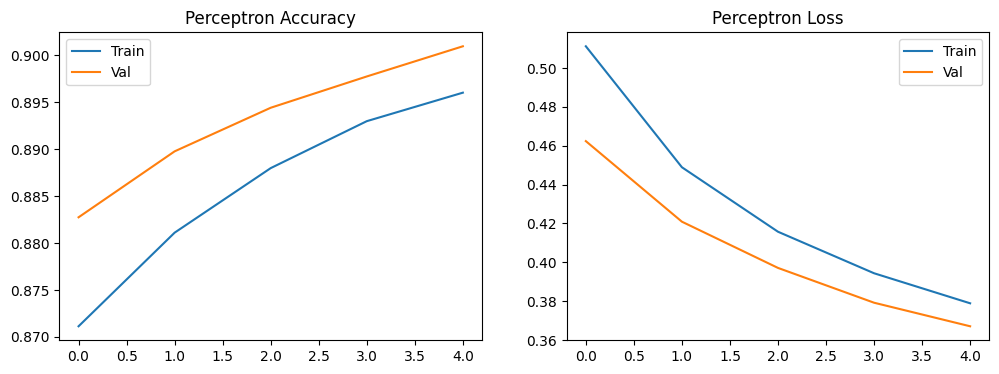

In [55]:
plot_training(history_percp, "Perceptron")


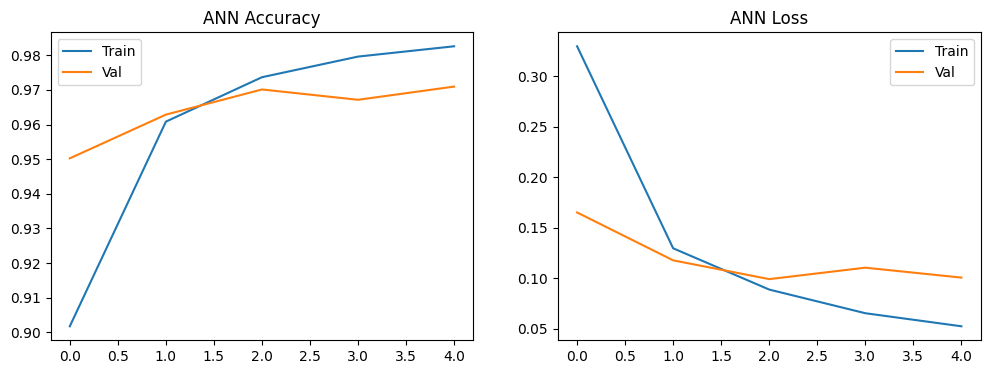

In [56]:
plot_training(history_ann, "ANN")

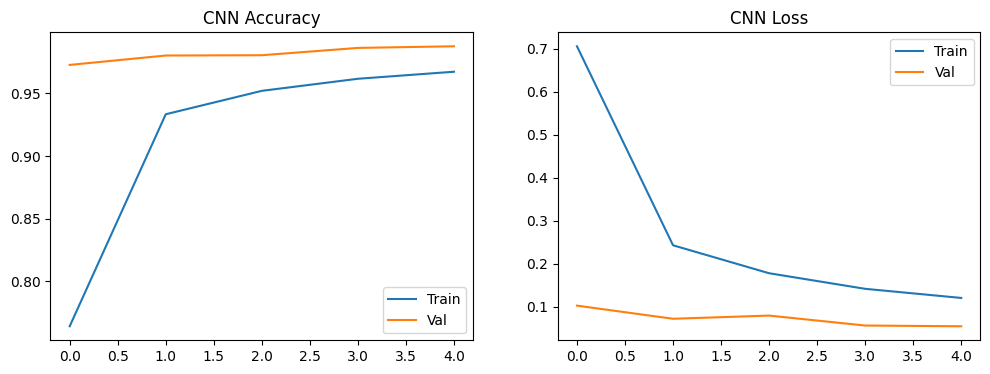

In [57]:
plot_training(history_cnn, "CNN")

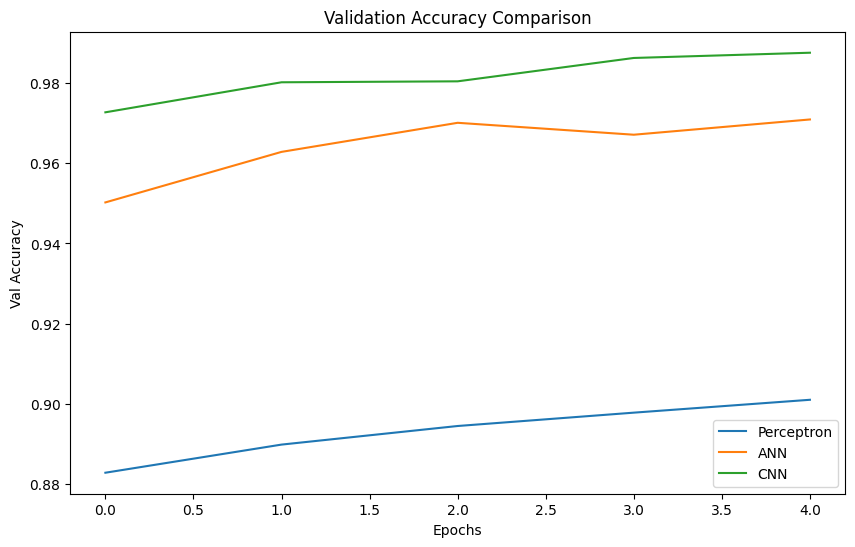

In [58]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [68]:
def show_side_by_side(models, model_names, X, X_cnn, y_true=None, n=5):

    for idx in range(n):

        plt.figure(figsize=(12, 3))

        # Show image
        plt.subplot(1, 4, 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")

        if y_true is not None:
            plt.title(f"True: {y_true[idx]}")
        else:
            plt.title("Test Image")

        # Predictions from each model
        for i, (model, name) in enumerate(zip(models, model_names)):

            plt.subplot(1, 4, i + 2)

            # CNN input
            if name == "CNN":
                img = X_cnn[idx].reshape(1, 28, 28, 1)
            else:
                img = X[idx].reshape(1, 28, 28)

            prediction = model.predict(img, verbose=0)
            predicted_label = np.argmax(prediction)

            plt.imshow(X[idx].reshape(28, 28), cmap="gray")
            plt.axis("off")
            plt.title(f"{name}\nPredicted: {predicted_label}")

        plt.tight_layout()
        plt.show()

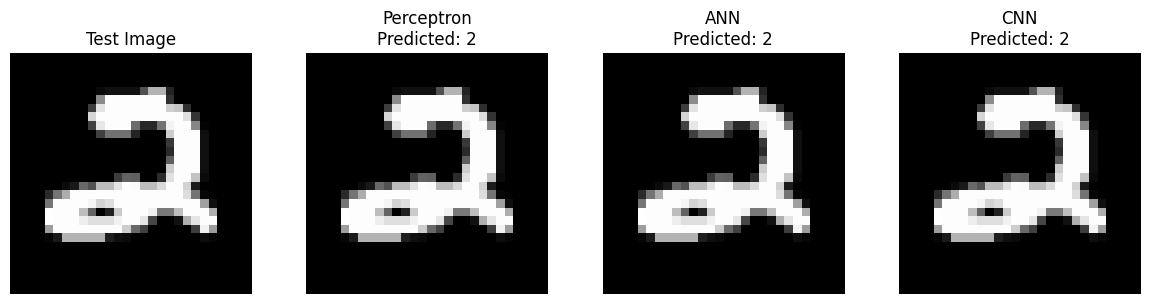

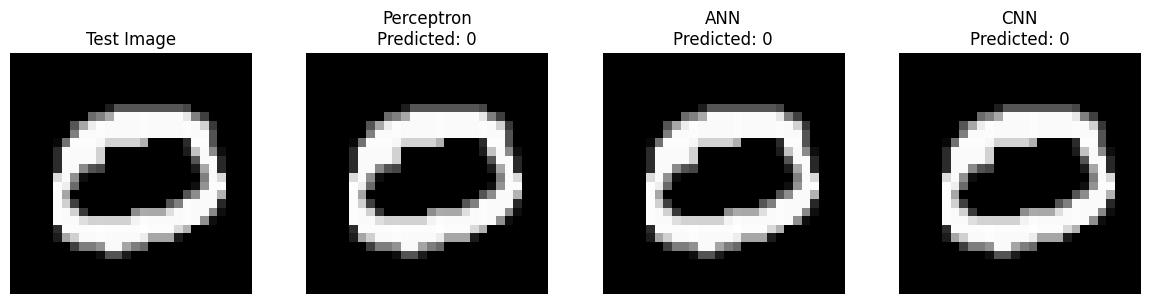

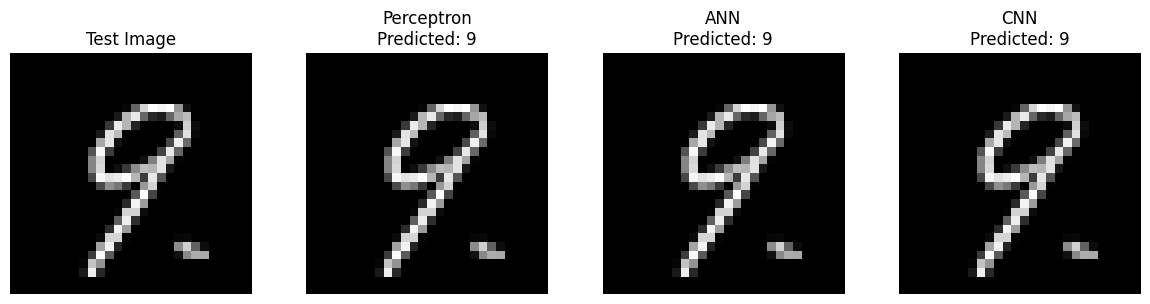

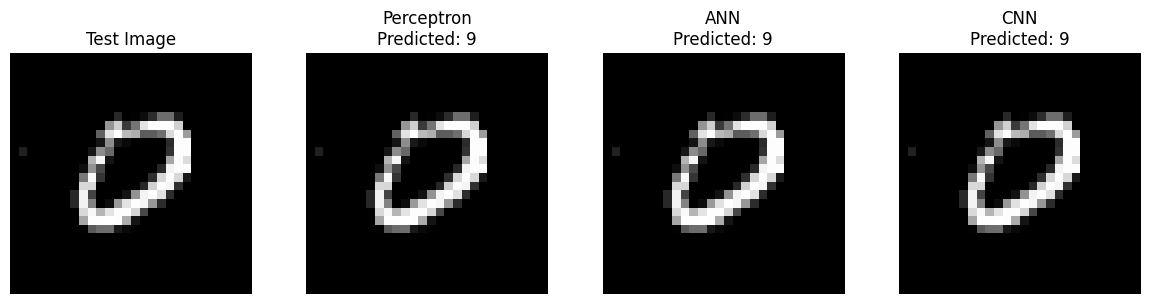

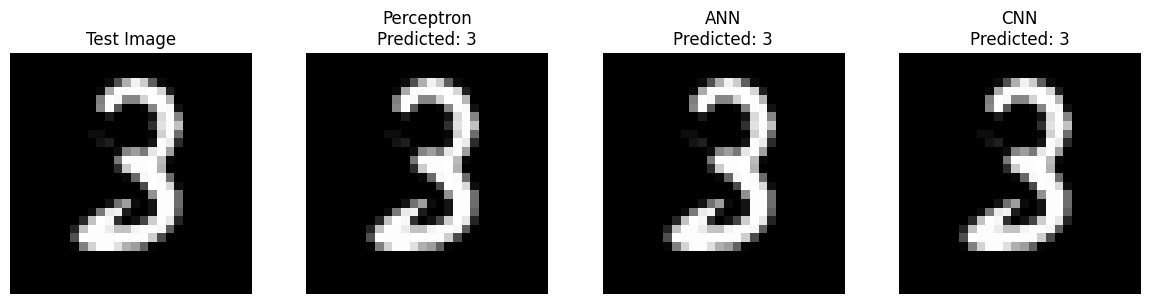

In [69]:
show_side_by_side(
    [perceptron, ann, cnn],
    ["Perceptron", "ANN", "CNN"],
    X_test_img,
    X_test_cnn,
    None,
    5
)

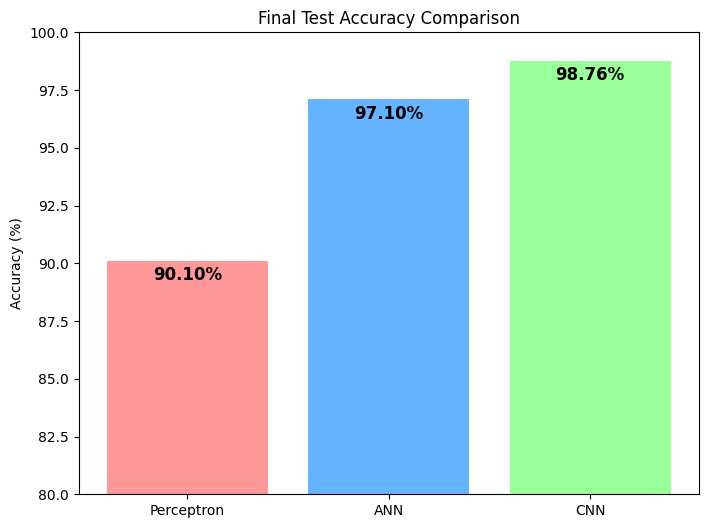

In [66]:

final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()